In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm import tqdm
from typing import Callable
from importlib import reload
import torchvision.transforms.v2 as v2
import matplotlib
import torchvision

SEED, STEPS, BATCH_SIZE = 42, 4000, 256
NOISE = 0.06  # Шум в координатах после деления на 10.
DEVICE = "auto"  # "auto", "cpu", "cuda:0", "cuda:1", ...
if DEVICE == "auto":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    device = torch.device(DEVICE)
if device.type == "cuda" and not torch.cuda.is_available():
    raise RuntimeError('CUDA недоступна: выберите DEVICE = "cpu" или "auto".')
torch.manual_seed(SEED)
torch.set_num_threads(2)  # Для маленьких MLP на CPU.
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
device_name = torch.cuda.get_device_name(device) if device.type == "cuda" else "CPU"
if (torch.xpu.is_available() and device_name == "CPU"):
    device_name = torch.xpu.get_device_name(0)
print(f"PyTorch {torch.__version__} | {device} ({device_name}) | seed={SEED}")

PyTorch 2.14.1+cpu | cpu (CPU) | seed=42


In [2]:
img_w, img_h, chanels = 64, 64, 3

In [3]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize([64, 64]),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 16
val_batch_size = 16


trainset = torchvision.datasets.CelebA(root='./data',
                                        download=True, transform=transform)
microtrainset, _ = torch.utils.data.random_split(trainset, [1000, len(trainset) - 1000])

trainloader = torch.utils.data.DataLoader(microtrainset, batch_size=batch_size,
                                          shuffle=True, num_workers=4)
valset = torchvision.datasets.CelebA(root='./data',
                                       download=True, transform=transform, split='valid')
microvalset, _ = torch.utils.data.random_split(valset, [100, len(valset) - 100])
valloader = torch.utils.data.DataLoader(microvalset, batch_size=val_batch_size, shuffle=True, num_workers=4)

# testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
#                                          shuffle=False, num_workers=2)

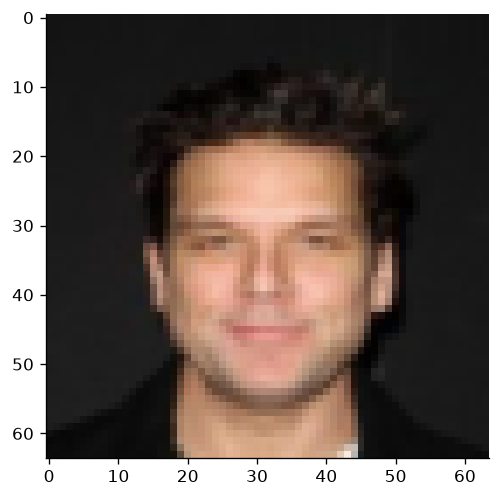

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, _ = next(dataiter)
# print(images, labels)
# show images
imshow(torchvision.utils.make_grid(images[0]))
# print()

In [5]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
        )

    def forward(self, x):
        return x + self.net(x)


def conv_net(c_in, c_out, hidden, n_blocks):
    layers = [nn.Conv2d(c_in, hidden, 3, padding=1), nn.ReLU()]
    for _ in range(n_blocks):
        layers.append(ResBlock(hidden))
        layers.append(nn.ReLU())
    layers.append(nn.Conv2d(hidden, c_out, 3, padding=1)) 
    bn = nn.BatchNorm2d(c_out)
    nn.init.zeros_(bn.weight)
    layers.append(bn)
    return nn.Sequential(*layers)

In [6]:
import nvp_model
reload(nvp_model)

hid_width = 3
blocks = 1

affineLayers1 = nn.ModuleList([*[nvp_model.AffineCoupling(nvp_model.checkerboard(chanels, img_h, img_w, i%2),
                                            conv_net(3, 3, hid_width, blocks),
                                            conv_net(3, 3, hid_width, blocks))
                                            for i in range(3)],
                 nvp_model.Squizer(False),
                 *[nvp_model.AffineCoupling(nvp_model.chanelwise(chanels * 4, img_h // 2, img_w // 2, i%2),
                                            conv_net(12, 12, hid_width, blocks),
                                            conv_net(12, 12, hid_width, blocks))
                                            for i in range(3)],
                 nvp_model.Squizer(True)])

scale1 = nvp_model.ScaleLayer(affineLayers1, img_h, img_w)

affineLayers2 = nn.ModuleList([*[nvp_model.AffineCoupling(nvp_model.checkerboard(chanels, img_h // 2, img_w // 2, i%2),
                                            conv_net(3, 3, hid_width * 2, blocks * 2),
                                            conv_net(3, 3, hid_width * 2, blocks * 2))
                                            for i in range(4)]])

scale2 = nvp_model.ScaleLayer(affineLayers2, img_h // 2, img_w // 2)

model = nvp_model.NVP(nn.ModuleList([scale1, scale2]))
# model.compile()

In [13]:
import nice_model
reload(nice_model)

<module 'nice_model' from '/home/alekseyka/projects/science school/nice_model.py'>

In [10]:
model.scale_layers[0].coupling_layers[4].masking.shape

torch.Size([12, 32, 32])

In [ ]:
def redraw(ax, history):
    npHist = np.array(history)
    ax.clear()
    ax.plot(npHist[:, 0], npHist[:, 1], label="valscore")
    ax.plot(npHist[:, 0], npHist[:, 2], label="trainscore")
    ax.legend()
    # ax.relim()
    # ax.autoscale_view()
    # fig.canvas.draw_idle()
    # fig.canvas.flush_events()
    
    # plt.pause(0.01)

100%|██████████| 10/10 [01:26<00:00,  8.64s/it]


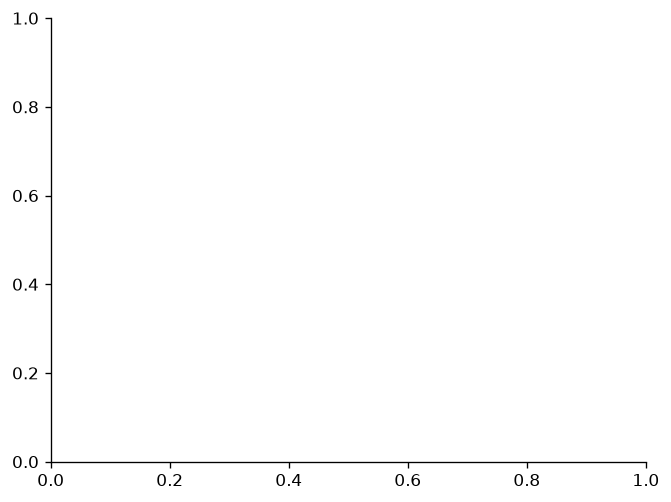

In [ ]:
history = []
model.train()
def record(step, model: nn.Module):
    with torch.no_grad():
        model.eval()
        X, _ = next(iter(valloader))
        # X = X.flatten(start_dim=1)
        with torch.no_grad():
            valscore = nice_model.loss_function(model(X), model.jacobian_det())
        X, _ = next(iter(trainloader))
        # X = X.flatten(start_dim=1)
        with torch.no_grad():
            trainscore = nice_model.loss_function(model(X), model.jacobian_det())
        history.append([step, valscore, trainscore])
    model.train()
# fig, ax = plt.subplots()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
steps = 0
# plt.ion()
for epoch in tqdm(range(10)):
    for X, _ in trainloader:
        optimizer.zero_grad()
        # X = X.flatten(start_dim=1)
        loss = nice_model.loss_function(model(X), model.jacobian_det())
        loss.backward()
        optimizer.step()
        if steps % 30 == 0:
            record(steps, model)
            # redraw(fig, ax, history)
        steps += 1
# plt.ioff()
# plt.show()

In [156]:
model.eval()

NVP(
  (scale_layers): ModuleList(
    (0): ScaleLayer(
      (coupling_layers): ModuleList(
        (0-2): 3 x AffineCoupling(
          (s): Sequential(
            (0): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): ReLU()
            (2): ResBlock(
              (net): Sequential(
                (0): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
                (1): ReLU()
                (2): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              )
            )
            (3): ReLU()
            (4): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (5): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          )
          (t): Sequential(
            (0): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): ReLU()
            (2): ResBlock(
              (net): Sequential(
                (0): Conv2d(3, 3, ke

In [157]:
def sample(n: int):
    res = torch.randn(n, chanels, img_h, img_w)
    with torch.no_grad():
        res = model.inverse(res)
    return res.reshape(n, chanels, img_h, img_w)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3978455..2.080997].


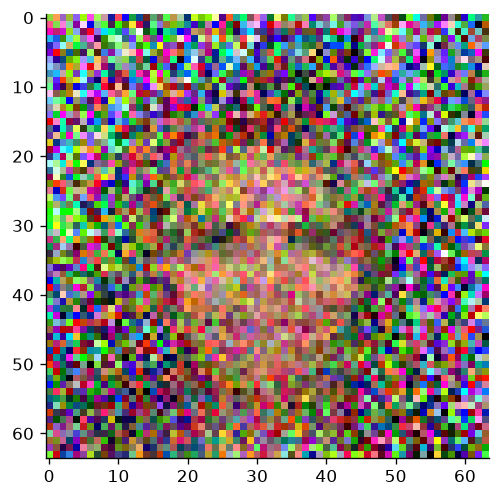

In [168]:
imgs = sample(1)
imshow(imgs[0])

In [88]:
record(0, model)

In [166]:
# import nvp_model
# reload(nvp_model)

# part = nvp_model.AffineCoupling(nvp_model.checkerboard(chanels, img_h, img_w, 0), conv_net(3,3,4,8), conv_net(3,3,4,8))
# part = deepcopy(scale2)
# paffineLayers1 = nn.ModuleList([nvp_model.AffineCoupling(nvp_model.checkerboard(chanels, img_h, img_w, False),
#                                             conv_net(3, 3, hid_width, blocks),
#                                             conv_net(3, 3, hid_width, blocks))])

# part = nvp_model.ScaleLayer(paffineLayers1, img_h, img_w)
part = model
# affineLayers2 = nn.ModuleList([*[nvp_model.AffineCoupling(nvp_model.checkerboard(chanels, img_h // 2, img_w // 2, i%2),
#                                             conv_net(3, 3, hid_width * 2, blocks * 2),
#                                             conv_net(3, 3, hid_width * 2, blocks * 2))
#                                             for i in range(4)]])

# scale2 = nvp_model.ScaleLayer(affineLayers2, img_h // 2, img_w // 2)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9924487..2.2840927].


tensor(307636.8438)
tensor(-307632.4688, grad_fn=<AddBackward0>)


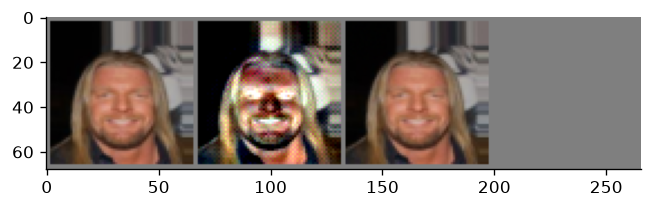

In [167]:
data, _ = next(iter(trainloader))
data = data[0:1]
# data0 = part
# part.train()
# optimizer = torch.optim.Adam(part.parameters(), 0.001)

# for batch, _ in trainloader:
#     # print(batch, type(batch))
#     optimizer.zero_grad()
#     out = part(batch)
#     loss = nice_model.loss_function(out, part.jacobian_det())
#     loss.backward()
#     optimizer.step()
part.eval()
with torch.no_grad():
    batch, _ = next(iter(trainloader))
    # print(batch, type(batch))
    out = part(batch)
    loss = nice_model.loss_function(out, part.jacobian_det())
    print(loss)
    print(part.jacobian_det())
data1 = model(data)
data2 = model.inverse(data1)
imshow(torchvision.utils.make_grid(torch.cat([data, data1, data2, data-data2])))
# imshow(torchvision.utils.make_grid(data1))
# imshow(torchvision.utils.make_grid(data2))
# data - data2

In [95]:
part.batch_norm.running_mean

tensor([[[ 6.0669e-02, -8.1597e+16,  6.1978e-02,  ...,  4.1813e+10,
           8.0625e-02,  9.4093e+08],
         [-9.6130e+16,  6.5371e-02,  3.9860e+17,  ...,  8.3613e-02,
           1.9398e+11,  7.7946e-02],
         [ 6.4118e-02, -1.1957e+19,  6.8815e-02,  ..., -2.3395e+14,
           8.1168e-02, -8.0568e+13],
         ...,
         [ 4.2130e+12, -1.4475e-01,  2.5775e+14,  ..., -4.1193e-02,
           5.9665e+14, -4.3968e-02],
         [-1.6048e-01, -3.0327e+11, -1.6783e-01,  ...,  2.1321e+15,
          -3.4488e-02,  9.3255e+12],
         [-1.3994e+09, -1.6951e-01, -9.0588e+11,  ..., -5.2608e-02,
          -2.6359e+12, -5.3316e-02]],

        [[ 1.7033e-02, -1.0483e+17,  6.7499e-03,  ..., -1.7152e+09,
           3.1994e-02, -1.2707e+08],
         [-1.9674e+17,  2.1156e-02, -2.3063e+18,  ...,  3.0870e-02,
          -9.8836e+11,  2.0830e-02],
         [ 2.1841e-02, -1.4871e+19,  2.5148e-02,  ..., -5.2362e+14,
           1.8834e-02, -1.4240e+14],
         ...,
         [-4.4932e+12, -2

In [74]:
X, _ = next(iter(valloader))
X.shape

torch.Size([256, 3, 64, 64])

In [132]:
history = np.array(history)

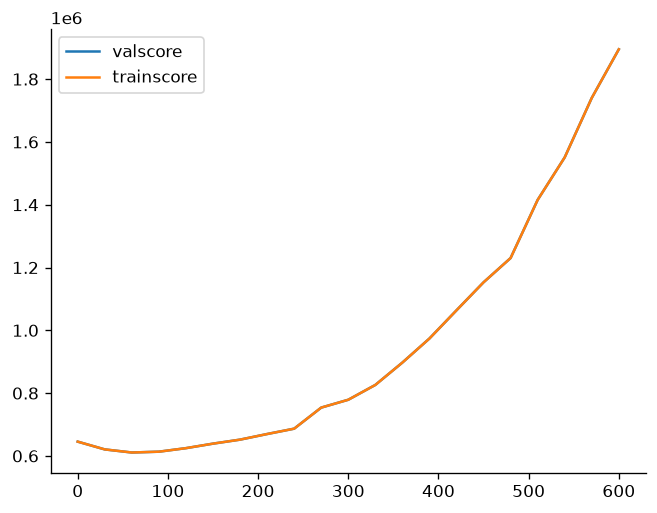

In [133]:
fig, ax = plt.subplots()

ax.plot(history[:, 0], history[:, 1], label="valscore")
ax.plot(history[:, 0], history[:, 2], label="trainscore")
ax.legend()
plt.show()

In [136]:
history[3]

array([9.00000000e+01, 6.13474250e+05, 6.13474062e+05])

In [7]:
torch.save(model.state_dict(), "./models/smart")

In [8]:
model.load_state_dict(torch.load("./models/smart", weights_only=True))

RuntimeError: Error(s) in loading state_dict for NVP:
	While copying the parameter named "scale_layers.0.coupling_layers.0.masking", whose dimensions in the model are torch.Size([3, 64, 64]) and whose dimensions in the checkpoint are torch.Size([3, 64, 64]), an exception occurred : ('unsupported operation: more than one element of the written-to tensor refers to a single memory location. Please clone() the tensor before performing the operation.',).
	While copying the parameter named "scale_layers.0.coupling_layers.1.masking", whose dimensions in the model are torch.Size([3, 64, 64]) and whose dimensions in the checkpoint are torch.Size([3, 64, 64]), an exception occurred : ('unsupported operation: more than one element of the written-to tensor refers to a single memory location. Please clone() the tensor before performing the operation.',).
	While copying the parameter named "scale_layers.0.coupling_layers.2.masking", whose dimensions in the model are torch.Size([3, 64, 64]) and whose

In [162]:
from matplotlib.animation import FuncAnimation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9079343..1.6945311].


torch.Size([3, 12288])
torch.Size([3, 3, 64, 64])
torch.Size([3, 68, 200])


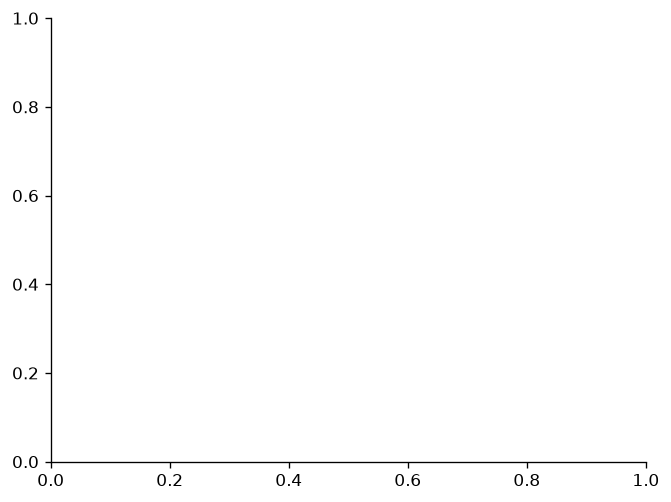

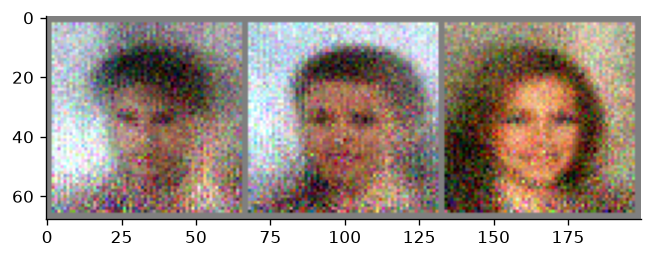

In [232]:
p1 = torch.randn(1, img_w * img_h * chanels)
p2 = torch.randn(1, img_w * img_h * chanels)
p3 = torch.randn(1, img_w * img_h * chanels)

ps = torch.cat([p1, p2, p3])
print(ps.shape)
with torch.no_grad():
    imgs = model.inverse(ps)
imgs = imgs.reshape(3, chanels, img_h, img_w)

fig, ax = plt.subplots()

print(imgs.shape)
img = torchvision.utils.make_grid(imgs)
print(img.shape)

fig, ax = plt.subplots()

img = img / 2 + 0.5     # unnormalize
npimg = img.numpy()
ax.imshow(np.transpose(npimg, (1, 2, 0)))
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2946291..1.1636306].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2946291..1.1636306].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.29556578..1.1778389].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.29618633..1.19165].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.29505926..1.2042663].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.29266834..1.2162251].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2903

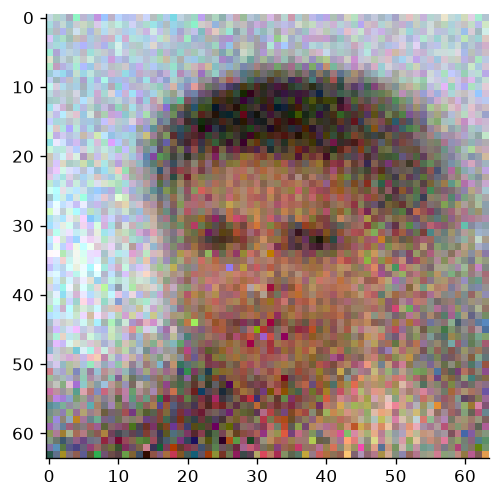

In [233]:
fig, ax = plt.subplots()

def update(alpha: float):
    ax.clear()
    a1 = np.sin(alpha * 2 * np.pi) / 3 + 1 / 3
    a2 = np.sin((alpha + 1 / 3) * 2 * np.pi) / 3 + 1 / 3
    a3 = np.sin((alpha - 1 / 3) * 2 * np.pi) / 3 + 1 / 3
    
    p = p1 * a1 + p2 * a2 + p3 * a3

    with torch.no_grad():
        img = model.inverse(p)
    img = img.reshape(chanels, img_h, img_w)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    return []

anim = FuncAnimation(fig=fig, func=update, frames=np.linspace(0, 1, 120), interval=20)

# plt.close(fig)
# plt.show()
anim.save("aboba.gif")